In [3]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt; plt.style.use('seaborn-v0_8-paper')
import seaborn as sns
from tqdm import tqdm
import os
from scipy import stats
# import scipy.stats as stats

import warnings; warnings.simplefilter(action='ignore', category=FutureWarning)

import sys; sys.path.append("/data/jerrylee/pjt/BIGFAM.v.0.1")
from BIGFAM import tools
from BIGFAM.obj1 import _slopeSig

# FRLog-reg

In [5]:
frlog_path = "/data/jerrylee/pjt/BIGFAM.v.0.1/data/GS/FRLogreg"
fns = os.listdir(frlog_path)
fns = [fn for fn in fns if fn.split(".")[-1] == "FRLOG"]
len(fns)

20

In [6]:
# merge results
df_frlog_mrg = pd.DataFrame()
for ii, fn in enumerate(fns):
    pheno_name = fn.split(".")[0]
    
    # load FRLog-reg results
    frlog_fn = f"{frlog_path}/{fn}"
    df_slopetest = pd.read_csv(frlog_fn, sep='\t')
    df_slopetest_wide = tools.long2wide(df_slopetest)
    
    # annotation
    df_slopetest_wide["pheno"] = pheno_name
    df_slopetest_wide["sig"] = "None"
    if (df_slopetest_wide["lower_slope"].values[0] > 1):
        df_slopetest_wide["sig"] = "High"
    if (df_slopetest_wide["upper_slope"].values[0] < 1):
        df_slopetest_wide["sig"] = "Low"
    
    df_frlog_mrg = pd.concat([df_frlog_mrg, df_slopetest_wide], axis=0)

df_frlog_mrg = df_frlog_mrg.reset_index(drop=True)
df_frlog_mrg.shape

(20, 8)

In [ ]:
# pheno_tb = pd.read_csv("/data/jerrylee/pjt/BIGFAM/data/id-pheno.table", sep='\t')
# df_frlog_mrg = df_frlog_mrg[df_frlog_mrg["pheno"].isin(pheno_tb["pheno"])]
# df_frlog_mrg.shape

In [7]:
df_frlog_mrg.groupby("sig").size()

sig
Low      9
None    11
dtype: int64

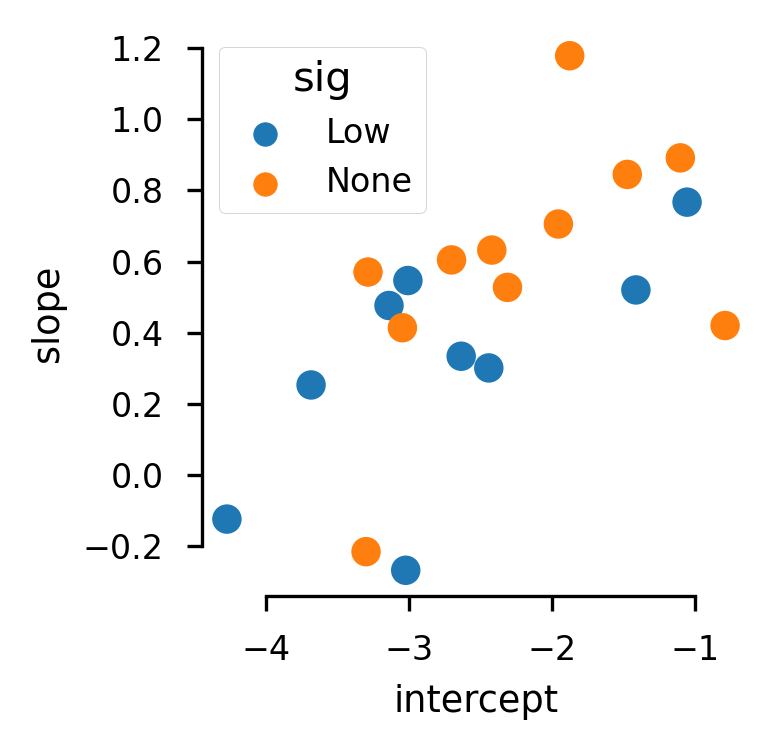

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(2.7, 2.6), dpi=300)

sns.scatterplot(x="intercept",
            y="slope",
            hue="sig",
            data=df_frlog_mrg,
            ax=ax,
            s=50,
            edgecolor="none")
# ax.legend([],[], frameon=False)
# ax.set_xticks([-4, -2, 0])
# ax.set_yticks([0.6, 1, 1.4])

sns.despine(offset=0.1, trim=True);

plt.tight_layout();
# plt.savefig("/data/jerrylee/pjt/BIGFAM/figures/GS_frlogreg.svg", 
#             dpi=300, 
#             format='svg')

# Prediction

In [18]:
obj1_path = "/data/jerrylee/pjt/BIGFAM.v.0.1/data/GS/obj1"

In [19]:
# functions to load data
def load_bigfam(path):
    pheno_fns = os.listdir(path)
    phenos = [pheno_fn.split(".")[0] for pheno_fn in pheno_fns]
    phenos = set(phenos)
    
    df_bigfam = pd.DataFrame()
    for pheno in tqdm(phenos):
        try:
            tmp = pd.read_csv(f"{path}/{pheno}.GSW", sep='\t')
            tmp["param"] = ["G_BIGFAM", "S_BIGFAM", "w_BIGFAM", "mse_train", "mse_test"]
            tmp_wide = tools.long2wide(tmp)
            
            tmp_sig = pd.read_csv(f"{path}/{pheno}.FRLOG_raw", sep='\t')
            sig = _slopeSig(tmp_sig["slope"])
            tmp_wide["pheno"] = pheno
            tmp_wide["sig"] = sig
            
            df_bigfam = pd.concat([df_bigfam, tmp_wide], axis=0)
        except:
            continue
    
    return df_bigfam.reset_index(drop=True)

In [20]:
# plot median with CI
def plotWithCI(df, xaxis, yaxis, ax, view_sig=False, do_reg=False):
    # parameters
    pnt_x_name = xaxis
    pnt_y_name = yaxis
    lower_x_name = f"lower_{pnt_x_name}"
    upper_x_name = f"upper_{pnt_x_name}"
    lower_y_name = f"lower_{pnt_y_name}"
    upper_y_name = f"upper_{pnt_y_name}"
    
    # plot frame
    sns.set_theme(style="ticks", palette="colorblind")
    
    # scatter plot
    sns.scatterplot(df,
                    x=pnt_x_name,
                    y=pnt_y_name,
                    s=30,
                    alpha=1,
                    ax=ax,
                    edgecolor=None)
    
    # CI
    if view_sig:
        ax.errorbar(x=df[pnt_x_name],
                    y=df[pnt_y_name],
                    xerr=[df[pnt_x_name] - df[lower_x_name], df[upper_x_name] - df[pnt_x_name]],
                    yerr=[df[pnt_y_name] - df[lower_y_name], df[upper_y_name] - df[pnt_y_name]],
                    alpha=0.7,
                    linewidth=1,
                    ls="",)
    
    slope, bse = -1, -1
    if do_reg:
        formula = f"{pnt_y_name} ~ 0 + {pnt_x_name}"
        min_x = 0.9 * df[pnt_x_name].min()
        max_x = 1.1 * df[pnt_x_name].max()
        xs = np.linspace(min_x, max_x, 100)
    
        ll = smf.ols(formula=formula, 
                     data=df).fit()
    
        slope = ll.params[pnt_x_name]
        bse = ll.bse[pnt_x_name]
        ys = slope * xs
        ax.plot(xs, ys, color="tab:blue", ls="--")
        ax.plot(xs, xs, color="lightgray", ls="--") # reference
        
    return slope, bse
    # sns.despine(offset=0.1, trim=True)
    # plt.tight_layout();

In [30]:
pheno_fns = os.listdir(obj1_path)
phenos = [pheno_fn.split(".")[0] for pheno_fn in pheno_fns]
phenos = set(phenos)

df_bigfam = pd.DataFrame()
for pheno in tqdm(phenos):
    try:
        tmp = pd.read_csv(f"{obj1_path}/{pheno}.GSW", sep='\t')
        
        tmp["param"] = ["G_BIGFAM", "S_BIGFAM", "w_BIGFAM", "mse_train", "mse_test"]
        tmp_wide = tools.long2wide(tmp)
        tmp_sig = pd.read_csv(f"{frlog_path}/{pheno}.FRLOG_raw", sep='\t')
        sig = _slopeSig(tmp_sig["slope"])
        tmp_wide["pheno"] = pheno
        tmp_wide["sig"] = sig
        
        df_bigfam = pd.concat([df_bigfam, tmp_wide], axis=0)
    except:
        continue

100%|██████████| 20/20 [00:00<00:00, 79.73it/s]


In [32]:
sig_G = df_bigfam["lower_G_BIGFAM"] > 1e-6
sig_S = df_bigfam["lower_S_BIGFAM"] > 1e-6
# sig_G = df_bigfam["lower_G_BIGFAM"] > 1e-6
for_plot = df_bigfam[sig_G & sig_S]
for_plot = for_plot[~(for_plot["pheno"] == "Seated_height")].reset_index(drop=True) # Seated, Seating height

for_plot.groupby("sig").size(), for_plot.shape[0]

(sig
 Low     7
 None    2
 dtype: int64,
 9)

In [33]:
for_plot.groupby("sig").agg(["mean", "std"])[["G_BIGFAM", "S_BIGFAM"]]

G_BIGFAM            S_BIGFAM          
          mean       std      mean       std
sig                                         
Low   0.193948  0.156840  0.055881  0.026921
None  0.317011  0.063453  0.061737  0.014675

TypeError: Got both 'ec' and 'edgecolor', which are aliases of one another

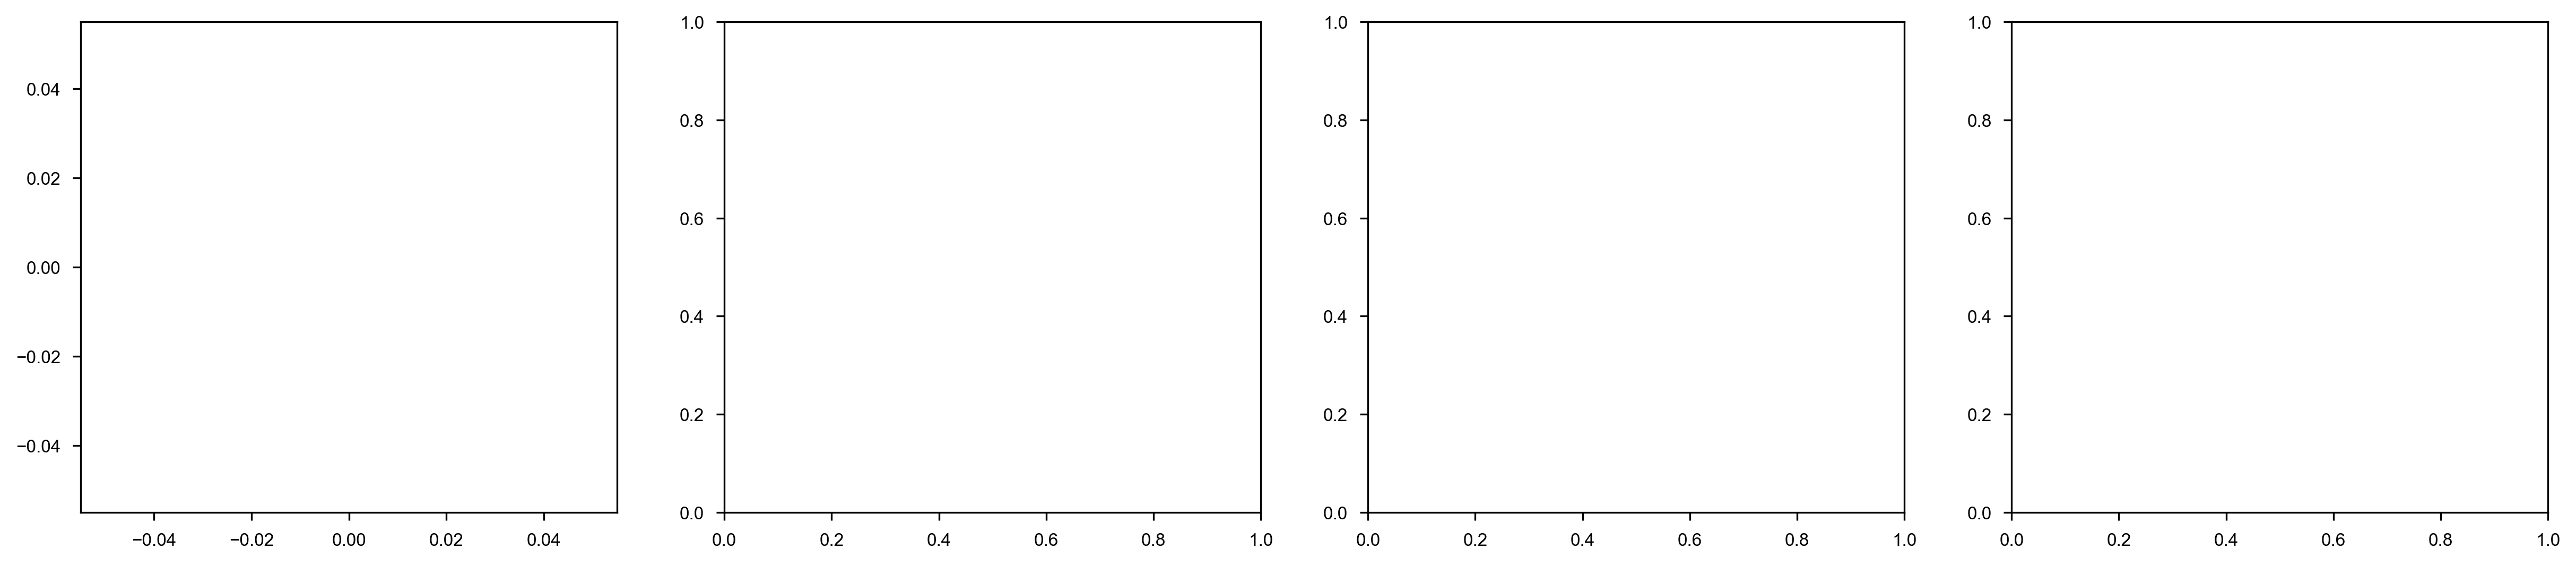

In [34]:
# [joint distribution on BIGFAM paramters]
fig, axs = plt.subplots(1, 4, figsize=(20, 4), dpi=300)

plotWithCI(for_plot, 
           xaxis="G_BIGFAM", 
           yaxis="S_BIGFAM", 
           ax=axs[0],
           view_sig=True)
axs[0].set_title("ALL")

for ri, sig in enumerate(for_plot["sig"].unique()):
    ax = axs[ri+1]
    
    plotWithCI(for_plot[for_plot["sig"] == sig], 
               xaxis="G_BIGFAM", 
               yaxis="S_BIGFAM", 
               ax=ax,
               view_sig=True)
    ax.set_title(sig)
    # ax.set_ylim([0, 0.1])

plt.tight_layout();
